# Exploratory Data Analysis: Comprehensive Hitmaker Prediction Dataset

This notebook provides a detailed exploration of the `df_comprehensive_hitmaker_prediction.csv` dataset, examining feature distributions, relationships, and patterns between 1-hit wonders and hitmakers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the comprehensive dataset
df = pd.read_csv('df_comprehensive_hitmaker_prediction.csv')
print("✓ Dataset loaded successfully")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Dataset loaded successfully
  Shape: 3,344 rows × 49 columns


## 1. Dataset Overview

In [2]:
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\n📊 BASIC INFORMATION")
print(f"  Total rows: {len(df):,}")
print(f"  Total columns: {df.shape[1]}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n📋 COLUMN DATA TYPES")
print(df.dtypes.value_counts())

print(f"\n🔍 FIRST FEW ROWS")
print(df.head())


DATASET OVERVIEW

📊 BASIC INFORMATION
  Total rows: 3,344
  Total columns: 49
  Memory usage: 1.29 MB

📋 COLUMN DATA TYPES
float64    34
int64      14
str         1
Name: count, dtype: int64

🔍 FIRST FEW ROWS
     performer_normalized  total_charting_songs  total_charting_albums  \
0  "little" jimmy dickens                     1                      0   
1     "weird al" yankovic                    11                      0   
2           & jack harlow                     1                      0   
3              & mystikal                     1                      0   
4                 'n sync                    12                      5   

   #1_hit_song_count  #1_hit_album_count  top_10_song_count  \
0                  0                   0                  0   
1                  0                   0                  1   
2                  1                   0                  1   
3                  0                   0                  0   
4                  1          

## 2. Target Variable Distribution


TARGET VARIABLE DISTRIBUTION

🎯 CLASS BALANCE
  1-Hit Wonders: 1,958 (58.6%)
  Hitmakers: 1,386 (41.4%)


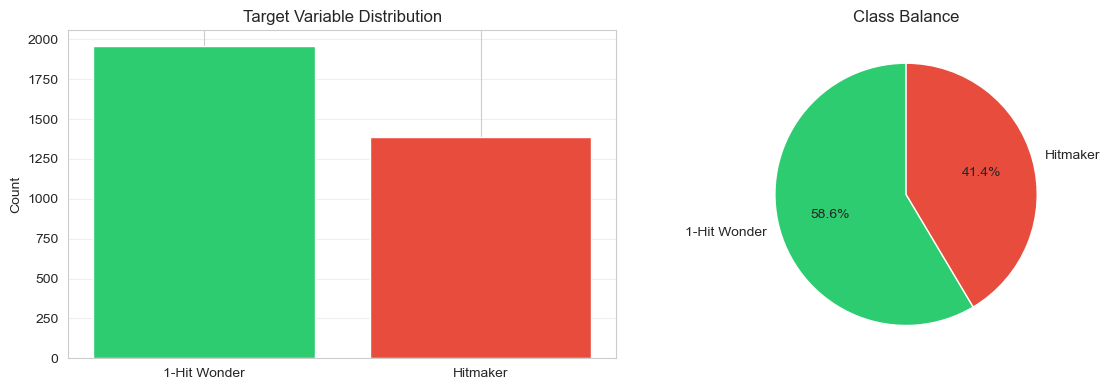

In [3]:
print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)

print(f"\n🎯 CLASS BALANCE")
target_counts = df['is_1hit_wonder'].value_counts()
print(f"  1-Hit Wonders: {target_counts.get(1, 0):,} ({target_counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"  Hitmakers: {target_counts.get(0, 0):,} ({target_counts.get(0, 0)/len(df)*100:.1f}%)")

# Plot target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_names = {1: '1-Hit Wonder', 0: 'Hitmaker'}
counts = df['is_1hit_wonder'].value_counts().sort_index(ascending=False)
ax1.bar([target_names[i] for i in counts.index], counts.values, color=['#2ecc71', '#e74c3c'])
ax1.set_ylabel('Count')
ax1.set_title('Target Variable Distribution')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(counts.values, labels=[target_names[i] for i in counts.index], autopct='%1.1f%%', 
        colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Class Balance')

plt.tight_layout()
plt.show()

## 3. Missing Values Analysis


MISSING VALUES ANALYSIS

⚠️ COLUMNS WITH MISSING VALUES: 24
                                  Column  Missing Count  Missing %
0      closeness_centrality_top10_yearly           2937  87.828947
1         degree_centrality_top10_yearly           2937  87.828947
2             google_trends_combined_avg           2874  85.944976
3              google_trends_youtube_avg           2874  85.944976
4                  google_trends_web_avg           2874  85.944976
5      degree_centrality_top10_rolling10           2745  82.087321
6   closeness_centrality_top10_rolling10           2745  82.087321
7     degree_centrality_top10_cumulative           2734  81.758373
8                  first_year_num1_songs           2582  77.212919
9    years_before_first_top_10_hit_album           2281  68.211722
10            first_year_on_chart_albums           1031  30.831340
11    years_before_first_top_10_hit_song            978  29.246411
12               first_year_top_10_songs            978  29.246411
1

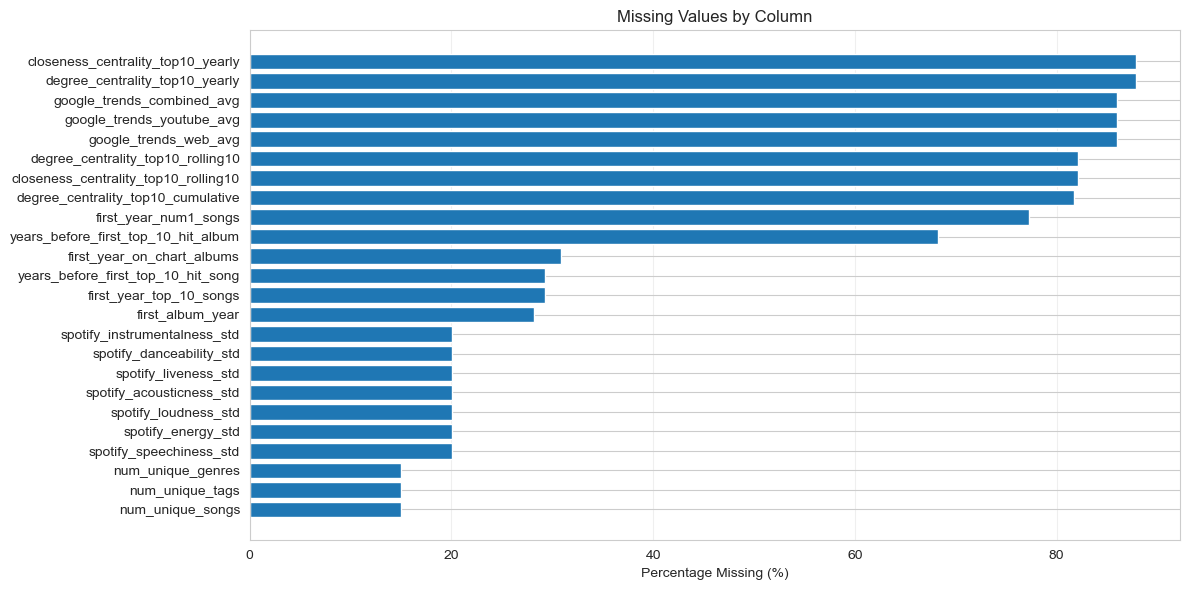

In [19]:
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

cols_with_missing = missing[missing > 0]

if len(cols_with_missing) > 0:
    print(f"\n⚠️ COLUMNS WITH MISSING VALUES: {len(cols_with_missing)}")
    missing_df = pd.DataFrame({
        'Column': cols_with_missing.index,
        'Missing Count': cols_with_missing.values,
        'Missing %': missing_pct[cols_with_missing.index].values
    }).reset_index(drop=True)
    print(missing_df.to_string())
    
    # Plot missing values
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df_sorted = missing_df.sort_values('Missing %', ascending=True)
    ax.barh(range(len(missing_df_sorted)), missing_df_sorted['Missing %'].values)
    ax.set_yticks(range(len(missing_df_sorted)))
    ax.set_yticklabels(missing_df_sorted['Column'].values)
    ax.set_xlabel('Percentage Missing (%)')
    ax.set_title('Missing Values by Column')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found!")

## 4. Numeric Features Summary Statistics

In [20]:
print("\n" + "="*80)
print("NUMERIC FEATURES SUMMARY")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nTotal numeric features: {len(numeric_cols)}")
print(f"\nDescriptive statistics:")
print(df[numeric_cols].describe().round(3))


NUMERIC FEATURES SUMMARY

Total numeric features: 49

Descriptive statistics:
       total_charting_songs  total_charting_albums  #1_hit_song_count  \
count              3344.000               3344.000           3344.000   
mean                  8.677                  4.576              0.423   
std                  16.362                  7.540              1.197   
min                   1.000                  0.000              0.000   
25%                   2.000                  0.000              0.000   
50%                   4.000                  2.000              0.000   
75%                   9.000                  6.000              0.000   
max                 361.000                127.000             20.000   

       #1_hit_album_count  top_10_song_count  top_10_album_count  \
count            3344.000           3344.000            3344.000   
mean                0.305              1.860               1.175   
std                 1.107              3.624               

## 5. Chart Performance Features


CHART PERFORMANCE ANALYSIS

📊 CHART METRICS BY TARGET
               total_charting_songs             total_charting_albums         \
                               mean median  max                  mean median   
is_1hit_wonder                                                                 
0                             16.63   10.0  361                  7.85    5.0   
1                              3.04    2.0   44                  2.26    1.0   

                    #1_hit_song_count            top_10_song_count             \
                max              mean median max              mean median max   
is_1hit_wonder                                                                  
0               109              0.87    0.0  20              3.66    2.0  81   
1               127              0.11    0.0   1              0.58    1.0   1   

               top_20_song_count              
                            mean median  max  
is_1hit_wonder                              

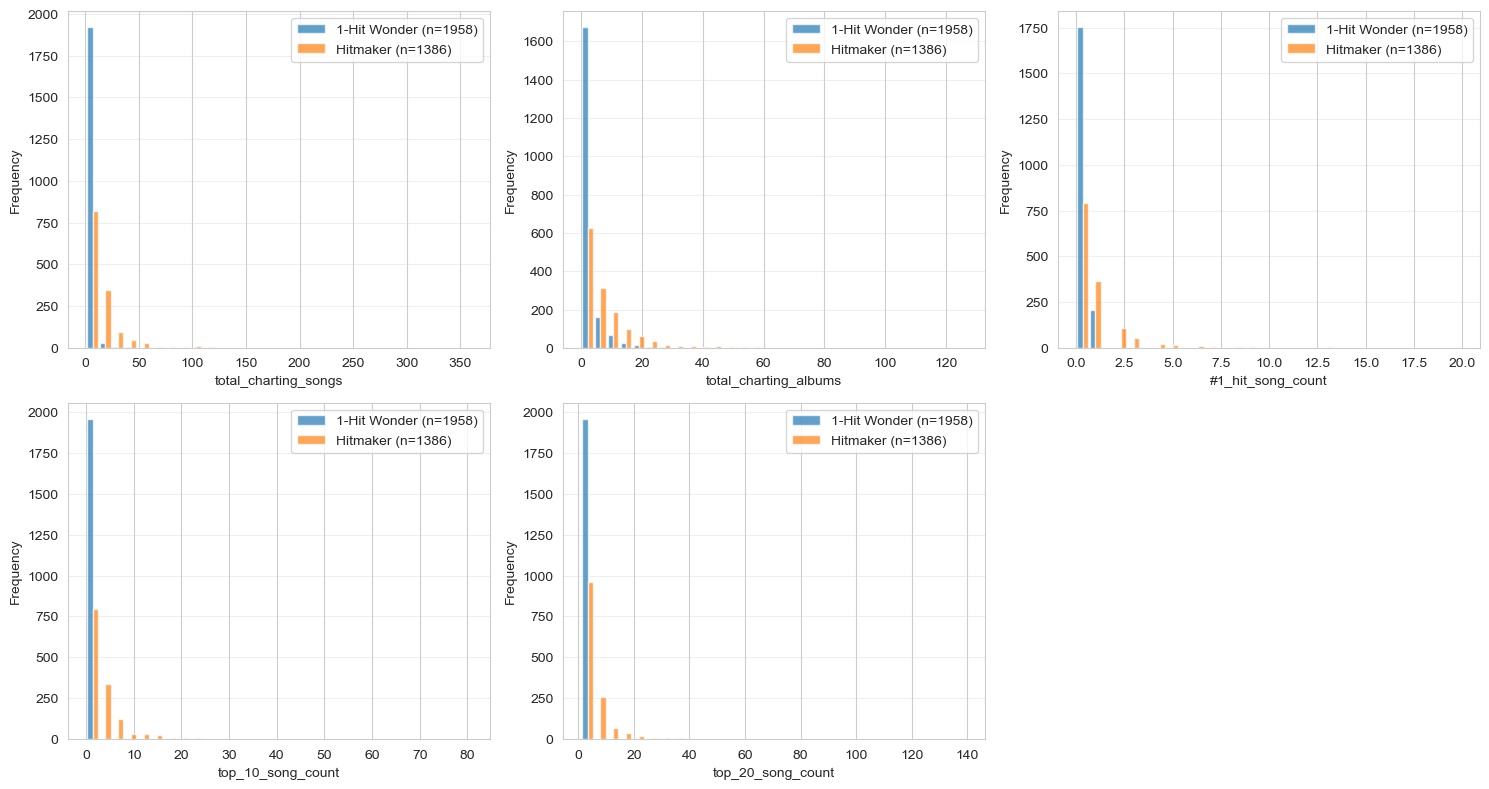

In [26]:
print("\n" + "="*80)
print("CHART PERFORMANCE ANALYSIS")
print("="*80)

chart_features = ['total_charting_songs', 'total_charting_albums', 
                  '#1_hit_song_count', 'top_10_song_count', 'top_20_song_count']

# Compare by target
print(f"\n📊 CHART METRICS BY TARGET")
comparison = df.groupby('is_1hit_wonder')[chart_features].agg(['mean', 'median', 'max'])
print(comparison.round(2))

# Calculate sample sizes
n_1hit = (df['is_1hit_wonder'] == 1).sum()
n_hitmaker = (df['is_1hit_wonder'] == 0).sum()

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(chart_features):
    ax = axes[idx]
    df_1hit = df[df['is_1hit_wonder'] == 1][col].dropna()
    df_hitmaker = df[df['is_1hit_wonder'] == 0][col].dropna()
    
    ax.hist([df_1hit, df_hitmaker], label=[f'1-Hit Wonder (n={n_1hit})', f'Hitmaker (n={n_hitmaker})'], bins=30, alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 6. Years Active on Charts Analysis


YEARS ACTIVE ON CHARTS

✓ Split columns found!

📅 YEARS ACTIVE STATISTICS
  Start year range: 1958 - 2026
  End year range: 1958 - 2026
  Duration range: 1 - 69 years
  Mean duration: 10.8 years

🎯 COMPARISON BY TARGET
                      1-Hit Wonder  Hitmaker
Avg Start Year              1985.7    1984.7
Avg End Year                1990.9    2001.0
Avg Duration (years)           6.2      17.4


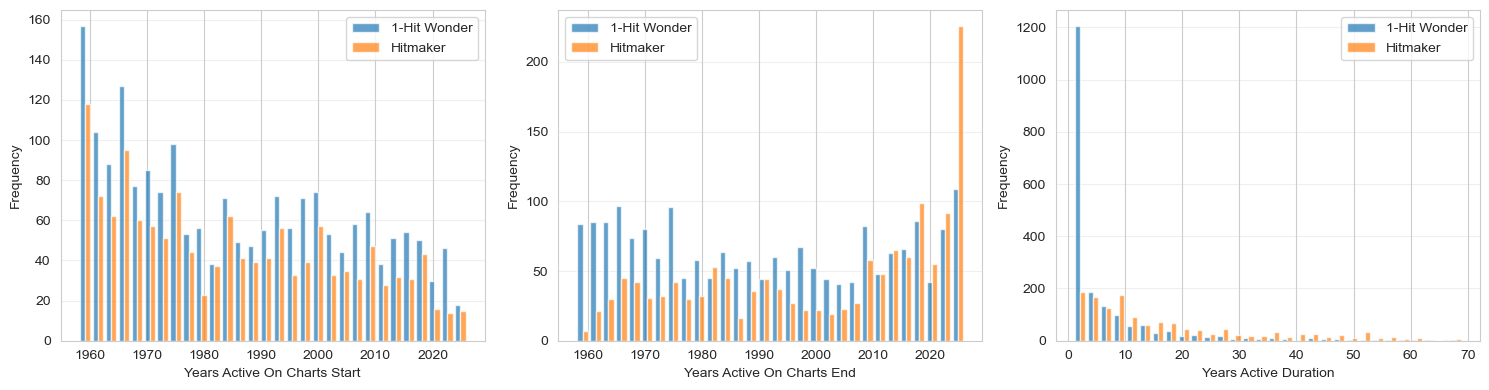

In [29]:
print("\n" + "="*80)
print("YEARS ACTIVE ON CHARTS")
print("="*80)

if 'years_active_on_charts_start' in df.columns and 'years_active_on_charts_end' in df.columns:
    print(f"\n✓ Split columns found!")
    
    # Calculate years active duration
    df['years_active_duration'] = df['years_active_on_charts_end'] - df['years_active_on_charts_start'] + 1
    
    print(f"\n📅 YEARS ACTIVE STATISTICS")
    print(f"  Start year range: {df['years_active_on_charts_start'].min():.0f} - {df['years_active_on_charts_start'].max():.0f}")
    print(f"  End year range: {df['years_active_on_charts_end'].min():.0f} - {df['years_active_on_charts_end'].max():.0f}")
    print(f"  Duration range: {df['years_active_duration'].min():.0f} - {df['years_active_duration'].max():.0f} years")
    print(f"  Mean duration: {df['years_active_duration'].mean():.1f} years")
    
    # Compare by target
    print(f"\n🎯 COMPARISON BY TARGET")
    comparison = pd.DataFrame({
        '1-Hit Wonder': [
            df[df['is_1hit_wonder']==1]['years_active_on_charts_start'].mean(),
            df[df['is_1hit_wonder']==1]['years_active_on_charts_end'].mean(),
            df[df['is_1hit_wonder']==1]['years_active_duration'].mean(),
        ],
        'Hitmaker': [
            df[df['is_1hit_wonder']==0]['years_active_on_charts_start'].mean(),
            df[df['is_1hit_wonder']==0]['years_active_on_charts_end'].mean(),
            df[df['is_1hit_wonder']==0]['years_active_duration'].mean(),
        ]
    }, index=['Avg Start Year', 'Avg End Year', 'Avg Duration (years)'])
    print(comparison.round(1))
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, col in zip(axes, ['years_active_on_charts_start', 'years_active_on_charts_end', 'years_active_duration']):
        df_1hit = df[df['is_1hit_wonder'] == 1][col].dropna()
        df_hitmaker = df[df['is_1hit_wonder'] == 0][col].dropna()
        
        ax.hist([df_1hit, df_hitmaker], label=['1-Hit Wonder', 'Hitmaker'], bins=30, alpha=0.7)
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Split columns not found in dataset")

## 7. Feature Correlations


FEATURE CORRELATIONS

🔗 TOP 15 CORRELATIONS WITH TARGET (is_1hit_wonder)
is_1hit_wonder                         1.000
highest_charting_song_position         0.470
spotify_loudness_mean                  0.280
first_year_on_chart_albums             0.063
first_album_year                       0.062
years_active_on_charts_start           0.025
first_year_on_chart_songs              0.025
first_song_year                        0.025
degree_centrality_top10_rolling10      0.020
degree_centrality_top10_cumulative    -0.000
first_year_top_10_songs               -0.002
spotify_instrumentalness_mean         -0.006
first_year_num1_songs                 -0.012
years_before_first_top_10_hit_album   -0.013
google_trends_web_avg                 -0.022
Name: is_1hit_wonder, dtype: float64

... (lowest correlations)
years_active_duration      -0.402
total_charting_songs       -0.409
top_10_song_count          -0.419
top_20_song_count          -0.432
spotify_acousticness_std   -0.438
spotify_loudness_

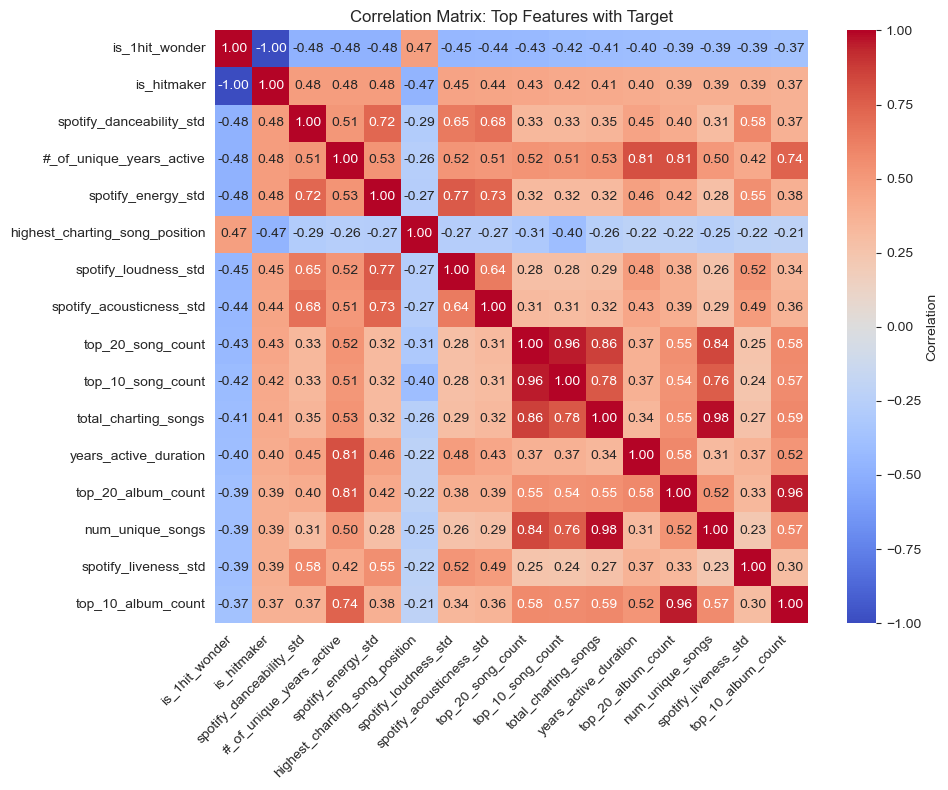

In [30]:
print("\n" + "="*80)
print("FEATURE CORRELATIONS")
print("="*80)

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Find correlations with target
target_corr = corr_matrix['is_1hit_wonder'].sort_values(ascending=False)
print(f"\n🔗 TOP 15 CORRELATIONS WITH TARGET (is_1hit_wonder)")
print(target_corr.head(15).round(3))
print(f"\n... (lowest correlations)")
print(target_corr.tail(10).round(3))

# Heatmap of top features
top_features = target_corr.abs().sort_values(ascending=False)[1:16].index.tolist()
top_features = ['is_1hit_wonder'] + top_features

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Top Features with Target')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Spotify Audio Features


SPOTIFY AUDIO FEATURES

Total Spotify features: 15
Spotify columns: ['spotify_acousticness_mean', 'spotify_acousticness_std', 'spotify_danceability_mean', 'spotify_danceability_std', 'spotify_energy_mean', 'spotify_energy_std', 'spotify_instrumentalness_mean', 'spotify_instrumentalness_std', 'spotify_liveness_mean', 'spotify_liveness_std']... (showing first 10)

📊 SPOTIFY FEATURES BY TARGET (mean values)
                spotify_acousticness_mean  spotify_danceability_mean  \
is_1hit_wonder                                                         
0                                   0.219                      0.499   
1                                   0.127                      0.297   

                spotify_energy_mean  spotify_instrumentalness_mean  \
is_1hit_wonder                                                       
0                             0.501                          0.021   
1                             0.298                          0.019   

                spoti

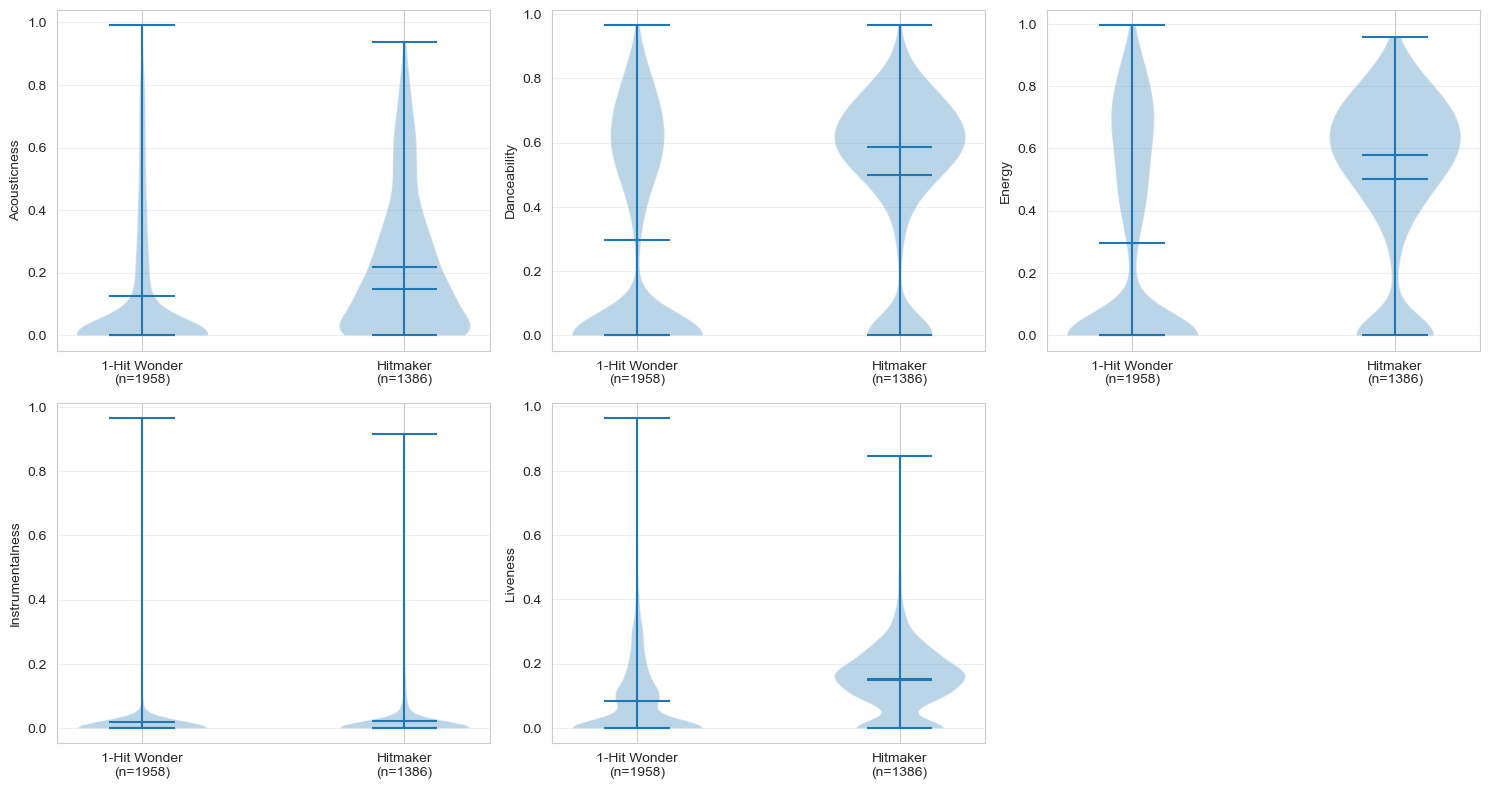

In [ ]:
print("\n" + "="*80)
print("SPOTIFY AUDIO FEATURES")
print("="*80)

spotify_cols = [col for col in df.columns if col.startswith('spotify_')]
print(f"\nTotal Spotify features: {len(spotify_cols)}")
print(f"Spotify columns: {spotify_cols[:10]}... (showing first 10)")

# Get mean features (exclude std)
spotify_mean_cols = [col for col in spotify_cols if '_mean' in col]

# Compare by target
print(f"\n📊 SPOTIFY FEATURES BY TARGET (mean values)")
spotify_comparison = df.groupby('is_1hit_wonder')[spotify_mean_cols].mean()
print(spotify_comparison.round(3))

# Calculate sample sizes
n_1hit = (df['is_1hit_wonder'] == 1).sum()
n_hitmaker = (df['is_1hit_wonder'] == 0).sum()

# Visualize with violin plots (better for distributions)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(spotify_mean_cols[:6]):
    ax = axes[idx]
    
    # Prepare data for violin plot
    plot_data = []
    labels = []
    for target, label in [(1, f'1-Hit Wonder\n(n={n_1hit})'), (0, f'Hitmaker\n(n={n_hitmaker})')]:
        plot_data.append(df[df['is_1hit_wonder'] == target][col].dropna().values)
        labels.append(label)
    
    parts = ax.violinplot(plot_data, positions=[1, 2], showmeans=True, showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel(col.replace('spotify_', '').replace('_mean', '').title())
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Histograms for the same features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(spotify_mean_cols[:6]):
    ax = axes[idx]
    df_1hit = df[df['is_1hit_wonder'] == 1][col].dropna()
    df_hitmaker = df[df['is_1hit_wonder'] == 0][col].dropna()
    
    ax.hist([df_1hit, df_hitmaker], label=[f'1-Hit Wonder (n={n_1hit})', f'Hitmaker (n={n_hitmaker})'], bins=30, alpha=0.7)
    ax.set_xlabel(col.replace('spotify_', '').replace('_mean', '').title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 9. Google Trends Analysis


GOOGLE TRENDS ANALYSIS

🔍 Google Trends Coverage
  google_trends_web_avg: 470/3,344 (14.1%)
  google_trends_youtube_avg: 470/3,344 (14.1%)
  google_trends_combined_avg: 470/3,344 (14.1%)

📊 GOOGLE TRENDS BY TARGET (among those with data)

google_trends_web_avg:
                 mean  median    std
is_1hit_wonder                      
0               23.15   20.10  14.38
1               21.61   19.04  11.06

google_trends_youtube_avg:
                 mean  median    std
is_1hit_wonder                      
0               27.92   29.60  13.85
1               20.90   18.69  11.95

google_trends_combined_avg:
                 mean  median    std
is_1hit_wonder                      
0               25.54   24.91  12.79
1               21.26   19.92  10.49


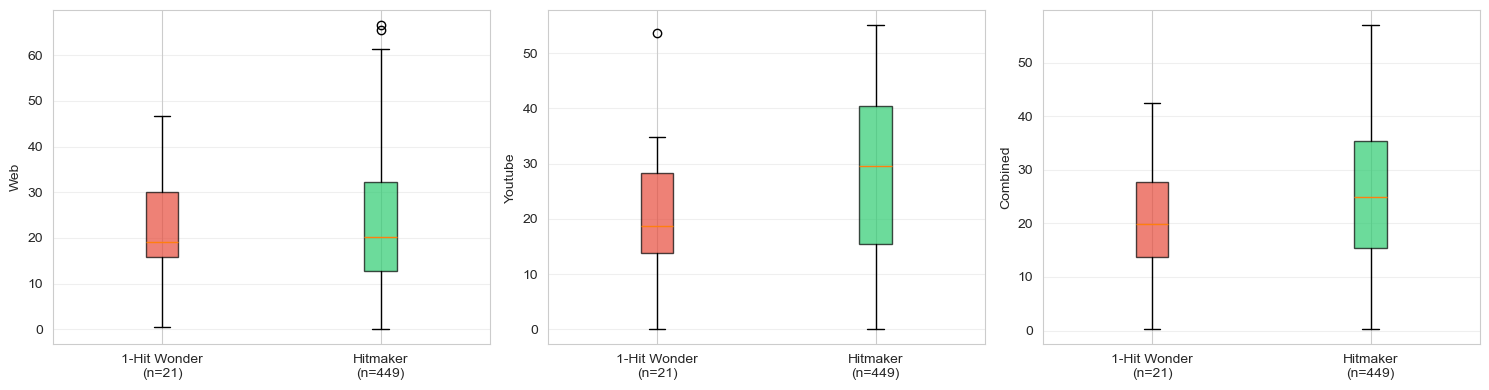

In [33]:
print("\n" + "="*80)
print("GOOGLE TRENDS ANALYSIS")
print("="*80)

trends_cols = [col for col in df.columns if col.startswith('google_trends_')]
print(f"\n🔍 Google Trends Coverage")

for col in trends_cols:
    coverage = df[col].notna().sum()
    pct = coverage / len(df) * 100
    print(f"  {col}: {coverage:,}/{len(df):,} ({pct:.1f}%)")

# Compare by target
print(f"\n📊 GOOGLE TRENDS BY TARGET (among those with data)")
for col in trends_cols:
    print(f"\n{col}:")
    df_with_trends = df[df[col].notna()]
    comparison = df_with_trends.groupby('is_1hit_wonder')[col].agg(['mean', 'median', 'std'])
    print(comparison.round(2))

# Visualize with box plots for better comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calculate sample sizes for Google Trends
for ax, col in zip(axes, trends_cols):
    df_plot = df[df[col].notna()]
    n_1hit_trends = (df_plot['is_1hit_wonder'] == 1).sum()
    n_hitmaker_trends = (df_plot['is_1hit_wonder'] == 0).sum()
    
    data_to_plot = [df_plot[df_plot['is_1hit_wonder'] == 1][col].values, 
                    df_plot[df_plot['is_1hit_wonder'] == 0][col].values]
    
    bp = ax.boxplot(data_to_plot, labels=[f'1-Hit Wonder\n(n={n_1hit_trends})', f'Hitmaker\n(n={n_hitmaker_trends})'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel(col.replace('google_trends_', '').replace('_avg', '').title())
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Genre Diversity


GENRE DIVERSITY ANALYSIS

🎵 GENRE FEATURES: ['num_unique_genres', 'num_unique_tags']

📊 GENRE METRICS BY TARGET
               num_unique_genres              num_unique_tags             
                            mean median   max            mean median   max
is_1hit_wonder                                                            
0                           4.23    4.0  23.0            5.73    5.0  34.0
1                           2.18    1.0  28.0            2.94    2.0  33.0


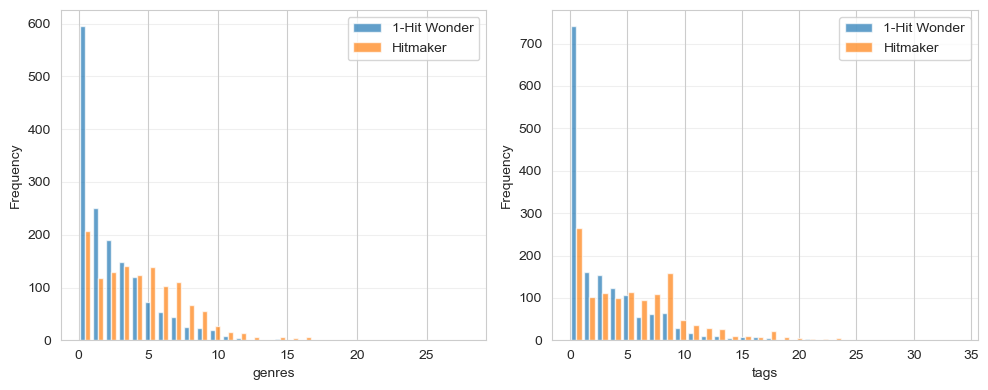

In [ ]:
print("\n" + "="*80)
print("GENRE DIVERSITY ANALYSIS")
print("="*80)

genre_cols = [col for col in df.columns if 'unique' in col and 'genre' in col or 'unique_tags' in col]
print(f"\n🎵 GENRE FEATURES: {genre_cols}")

# Compare by target
print(f"\n📊 GENRE METRICS BY TARGET")
comparison = df.groupby('is_1hit_wonder')[genre_cols].agg(['mean', 'median', 'max'])
print(comparison.round(2))

# Visualize with box plots for better comparison
fig, axes = plt.subplots(1, len(genre_cols), figsize=(5*len(genre_cols), 4))
if len(genre_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, genre_cols):
    data_1hit = df[df['is_1hit_wonder'] == 1][col].dropna()
    data_hitmaker = df[df['is_1hit_wonder'] == 0][col].dropna()
    n_1hit_genre = len(data_1hit)
    n_hitmaker_genre = len(data_hitmaker)
    
    data_to_plot = [data_1hit.values, data_hitmaker.values]
    
    bp = ax.boxplot(data_to_plot, labels=[f'1-Hit Wonder\n(n={n_1hit_genre})', f'Hitmaker\n(n={n_hitmaker_genre})'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel(col.replace('num_unique_', '').title())
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Summary & Key Insights

In [ ]:
print("\n" + "="*80)
print("SUMMARY & KEY INSIGHTS")
print("="*80)

print(f"\n📌 DATASET CHARACTERISTICS")
print(f"  • Total artists: {len(df):,}")
print(f"  • Features: {df.shape[1]}")
print(f"  • Class balance: {(df['is_1hit_wonder']==1).sum():,} 1-hit wonders vs {(df['is_1hit_wonder']==0).sum():,} hitmakers")

print(f"\n🔑 TOP PREDICTIVE FEATURES (by correlation with target)")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top_features = df[numeric_cols].corr()['is_1hit_wonder'].abs().sort_values(ascending=False)[1:11]
for i, (col, val) in enumerate(top_features.items(), 1):
    print(f"  {i}. {col}: {val:.3f}")

print(f"\n📊 FEATURE COMPLETENESS")
print(f"  • Columns with no missing values: {(df.isnull().sum() == 0).sum()}/{df.shape[1]}")
print(f"  • Columns with <5% missing: {((df.isnull().sum()/len(df)) < 0.05).sum()}/{df.shape[1]}")

print(f"\n✓ DATASET READY FOR MODELING")